# Sales Forecasting - Visualization

## Load predictions

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

preds = pd.read_csv("outputs/predictions.csv", parse_dates=["Order Date"])
preds.head()

,Order Date,Sales,predicted_sales
0,2017-03-15,0.000,495.373260
1,2017-03-16,2014.381,3041.522628
2,2017-03-17,542.746,1618.302446
3,2017-03-18,1027.758,1478.509402
4,2017-03-19,2166.248,1625.522888


## Actual vs predicted sales

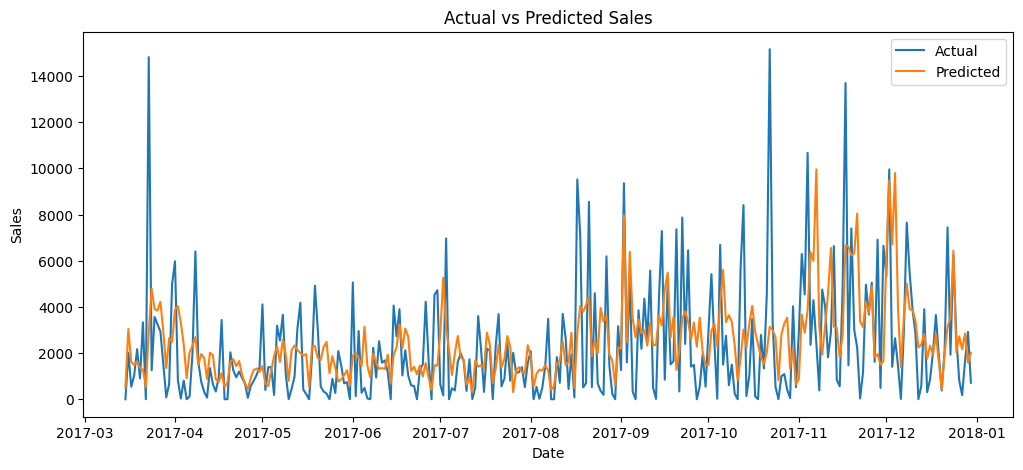

In [6]:
plt.figure(figsize=(12,5))
plt.plot(preds["Order Date"], preds["Sales"], label="Actual")
plt.plot(preds["Order Date"], preds["predicted_sales"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

## Monthly sales trend

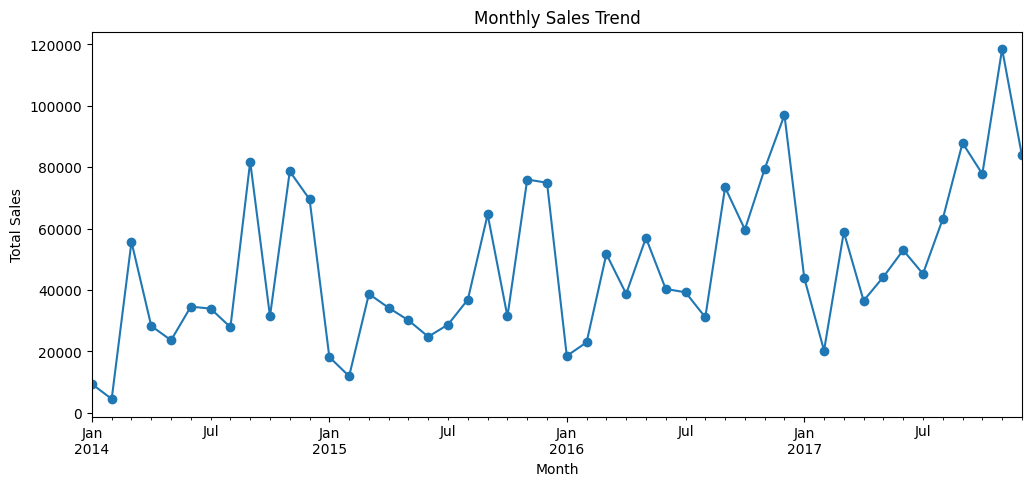

In [7]:
cleaned = pd.read_csv("outputs/cleaned_data.csv", parse_dates=["Order Date"])
monthly = cleaned.groupby(cleaned["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(12,5))
monthly.plot(kind="line", marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.show()

## Error distribution

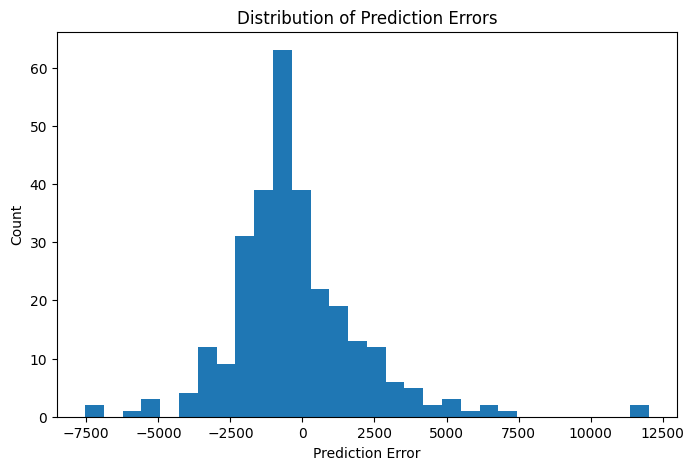

In [8]:
errors = preds["Sales"] - preds["predicted_sales"]

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.show()

## Forecast for next 30 days

In [9]:
future = pd.read_csv("outputs/future_predictions.csv", parse_dates=["Order Date"])
future.head()

,Order Date,predicted_sales
0,2017-12-31,1729.624161
1,2018-01-01,2349.445195
2,2018-01-02,2125.732820
3,2018-01-03,677.858608
4,2018-01-04,2923.059140


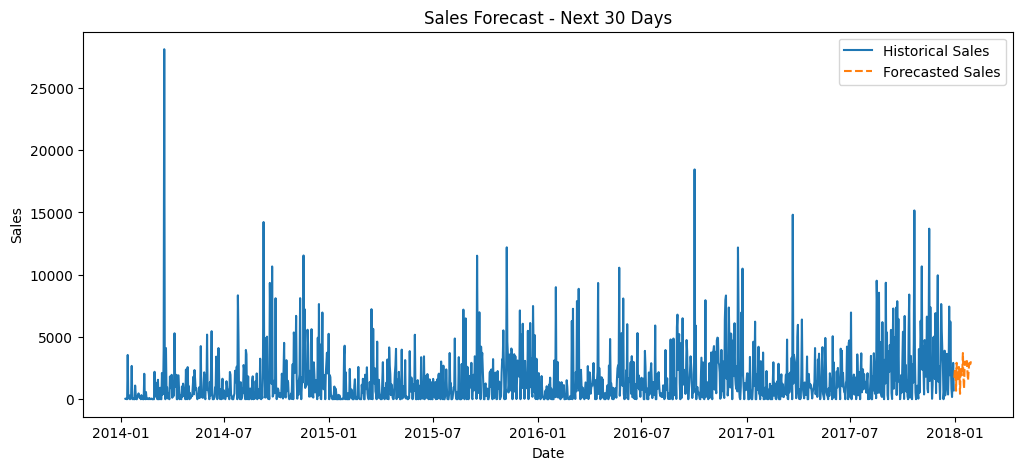

In [10]:
plt.figure(figsize=(12,5))
plt.plot(cleaned["Order Date"], cleaned["Sales"], label="Historical Sales")
plt.plot(future["Order Date"], future["predicted_sales"], label="Forecasted Sales", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Forecast - Next 30 Days")
plt.legend()
plt.show()

## What this means

The model follows the overall sales trend well, though it misses some of the sudden spikes since those are harder to predict from past patterns alone.

For a business, this kind of forecast can help with:
- planning inventory ahead of high sales periods
- deciding staffing levels month to month
- spotting slow periods early so cash flow can be managed better

The monthly trend chart shows sales are not flat throughout the year, so planning around a single average would not be accurate. A store owner could use this forecast to prepare stock levels 1-2 months in advance instead of reacting late.